# VytalLink Health Chat Demo

End-to-end hackathon notebook: load real VytalLink data, compute readiness, generate an LLM narrative, and chat about the same health window.

## Observability First

Recommended demo order:

1. Start the local telemetry stack with `make obs-up`.
2. Open Grafana at `http://localhost:3000` and keep the `VytalLink App` dashboard visible.
3. Optionally open Jaeger at `http://localhost:16686` and LangSmith for traces.
4. Run this notebook from top to bottom.
5. Watch VytalLink request metrics during fetch, then LLM metrics during the narrative and chat sections.

If `OTEL_EXPORTER_OTLP_ENDPOINT` is configured but the collector is not running, the app will skip OTEL export and continue normally.

## 1. Setup

In [1]:
from datetime import date
from dataclasses import dataclass

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import Markdown, display

from vytallink_health_kit.application.use_cases import (
    BuildReadinessReportInput,
    BuildReadinessReportUseCase,
    ChatWithHealthDataInput,
    ChatWithHealthDataUseCase,
)
from vytallink_health_kit.infrastructure.llm import LLMNarrativeGenerator
from vytallink_health_kit.infrastructure.observability import initialize_observability
from vytallink_health_kit.infrastructure.settings import (
    load_llm_settings,
    load_observability_settings,
    load_vytallink_settings,
)
from vytallink_health_kit.infrastructure.vytallink_client import VytalLinkRESTClient
from vytallink_health_kit.infrastructure.vytallink_client import VytalLinkClientError
from vytallink_health_kit.domain.entities import HealthData

load_dotenv()
obs_settings = initialize_observability(load_observability_settings())
vytallink_settings = load_vytallink_settings()
llm_settings = load_llm_settings()

provider = VytalLinkRESTClient(settings=vytallink_settings)
generator = LLMNarrativeGenerator(settings=llm_settings)
readiness_use_case = BuildReadinessReportUseCase(
    health_data_provider=provider,
    narrative_generator=generator,
)
chat_use_case = ChatWithHealthDataUseCase(
    health_data_provider=provider,
    narrative_generator=generator,
)

DEMO_END_DATE = date.today()
DEMO_DAYS = 7

@dataclass(slots=True)
class StaticHealthDataProvider:
    health_data: HealthData

    def fetch_window(self, *, end_date: date, days: int) -> HealthData:
        return self.health_data

print(
    {
        "base_url": vytallink_settings.base_url,
        "api_mode": vytallink_settings.api_mode,
        "llm_provider": llm_settings.llm_provider,
        "request_timeout_seconds": vytallink_settings.timeout_seconds,
        "metrics_timeout_seconds": vytallink_settings.metrics_timeout_seconds,
        "metrics_request_interval_seconds": vytallink_settings.metrics_request_interval_seconds,
        "otel_endpoint": obs_settings.otel_exporter_otlp_endpoint,
        "service_name": obs_settings.otel_service_name,
        "window": {"end_date": DEMO_END_DATE.isoformat(), "days": DEMO_DAYS},
    }
)

display(
    Markdown(
        """
### Live Telemetry Checklist

- Start the stack with `make obs-up`
- Grafana: `http://localhost:3000`
- Jaeger: `http://localhost:16686`
- Run the fetch cell and check VytalLink API traffic
- Run the narrative/chat cells and check LLM latency and traces
"""
    )
)


{'base_url': 'https://vytallink.local.xmartlabs.com', 'api_mode': 'auto', 'llm_provider': 'openai', 'request_timeout_seconds': 15.0, 'metrics_timeout_seconds': 45.0, 'metrics_request_interval_seconds': 1.0, 'otel_endpoint': 'http://localhost:4317', 'service_name': 'vytallink-health-kit', 'window': {'end_date': '2026-03-26', 'days': 7}}



### Live Telemetry Checklist

- Start the stack with `make obs-up`
- Grafana: `http://localhost:3000`
- Jaeger: `http://localhost:16686`
- Run the fetch cell and check VytalLink API traffic
- Run the narrative/chat cells and check LLM latency and traces


## 2. Fetch Data

In [2]:
try:
    health_data = provider.fetch_window(end_date=DEMO_END_DATE, days=DEMO_DAYS)
except VytalLinkClientError as exc:
    raise RuntimeError(
        "VytalLink data fetch failed. The server may be saturated. "
        "Retry the cell in a moment or increase VYTALLINK_METRICS_TIMEOUT_SECONDS in .env. "
        f"Original error: {exc}"
    ) from exc

print(
    {
        "available_days": health_data.available_days,
        "missing_days": [day.isoformat() for day in health_data.missing_days],
    }
)

rows = []
for day in health_data.days:
    iso_day = day.isoformat()
    sleep = health_data.sleep.get(iso_day)
    hr = health_data.heart_rate.get(iso_day)
    activity = health_data.activity.get(iso_day)
    rows.append(
        {
            "date": day,
            "sleep_total_minutes": getattr(sleep, "total_minutes", None),
            "sleep_awake_minutes": getattr(sleep, "awake_minutes", None),
            "resting_hr_bpm": getattr(hr, "resting_bpm", None),
            "activity_steps": getattr(activity, "steps", None),
            "activity_calories": getattr(activity, "active_calories", None),
            "activity_exercise_minutes": getattr(activity, "exercise_minutes", None),
        }
    )

health_df = pd.DataFrame(rows)

static_provider = StaticHealthDataProvider(health_data=health_data)
readiness_use_case = BuildReadinessReportUseCase(
    health_data_provider=static_provider,
    narrative_generator=generator,
)
chat_use_case = ChatWithHealthDataUseCase(
    health_data_provider=static_provider,
    narrative_generator=generator,
)

print("Health data cached in-memory for the rest of the notebook.")
health_df


{"method": "GET", "path": "/sleep", "metric_name": "sleep", "event": "vytallink_request_started", "level": "info", "timestamp": "2026-03-26T16:25:08.208208Z"}
HTTP Request: GET https://vytallink.local.xmartlabs.com/sleep?start_date=2026-03-20&end_date=2026-03-26&word=mountain&code=517432 "HTTP/1.1 404 Not Found"
{"method": "GET", "path": "/sleep", "metric_name": "sleep", "duration_ms": 161.5, "status_code": 404, "status": "error", "event": "vytallink_request_completed", "level": "info", "timestamp": "2026-03-26T16:25:08.369769Z"}
{"method": "POST", "path": "/api/direct-login", "metric_name": "direct_login", "event": "vytallink_request_started", "level": "info", "timestamp": "2026-03-26T16:25:08.370082Z"}
HTTP Request: POST https://vytallink.local.xmartlabs.com/api/direct-login "HTTP/1.1 200 OK"
{"method": "POST", "path": "/api/direct-login", "metric_name": "direct_login", "duration_ms": 96.65, "status_code": 200, "status": "success", "event": "vytallink_request_completed", "level": "in

,date,sleep_total_minutes,sleep_awake_minutes,resting_hr_bpm,activity_steps,activity_calories,activity_exercise_minutes
0,2026-03-20,415.0,31.0,48.0,4735,None,None
1,2026-03-21,455.0,81.0,48.0,10060,None,None
2,2026-03-22,NaN,NaN,57.0,9803,None,None
3,2026-03-23,329.0,7.0,47.0,7516,None,None
4,2026-03-24,53.0,12.0,47.0,4568,None,None
5,2026-03-25,408.0,8.0,49.0,5950,None,None
6,2026-03-26,325.0,12.0,63.0,1647,None,None


## 3. Visualize

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings 

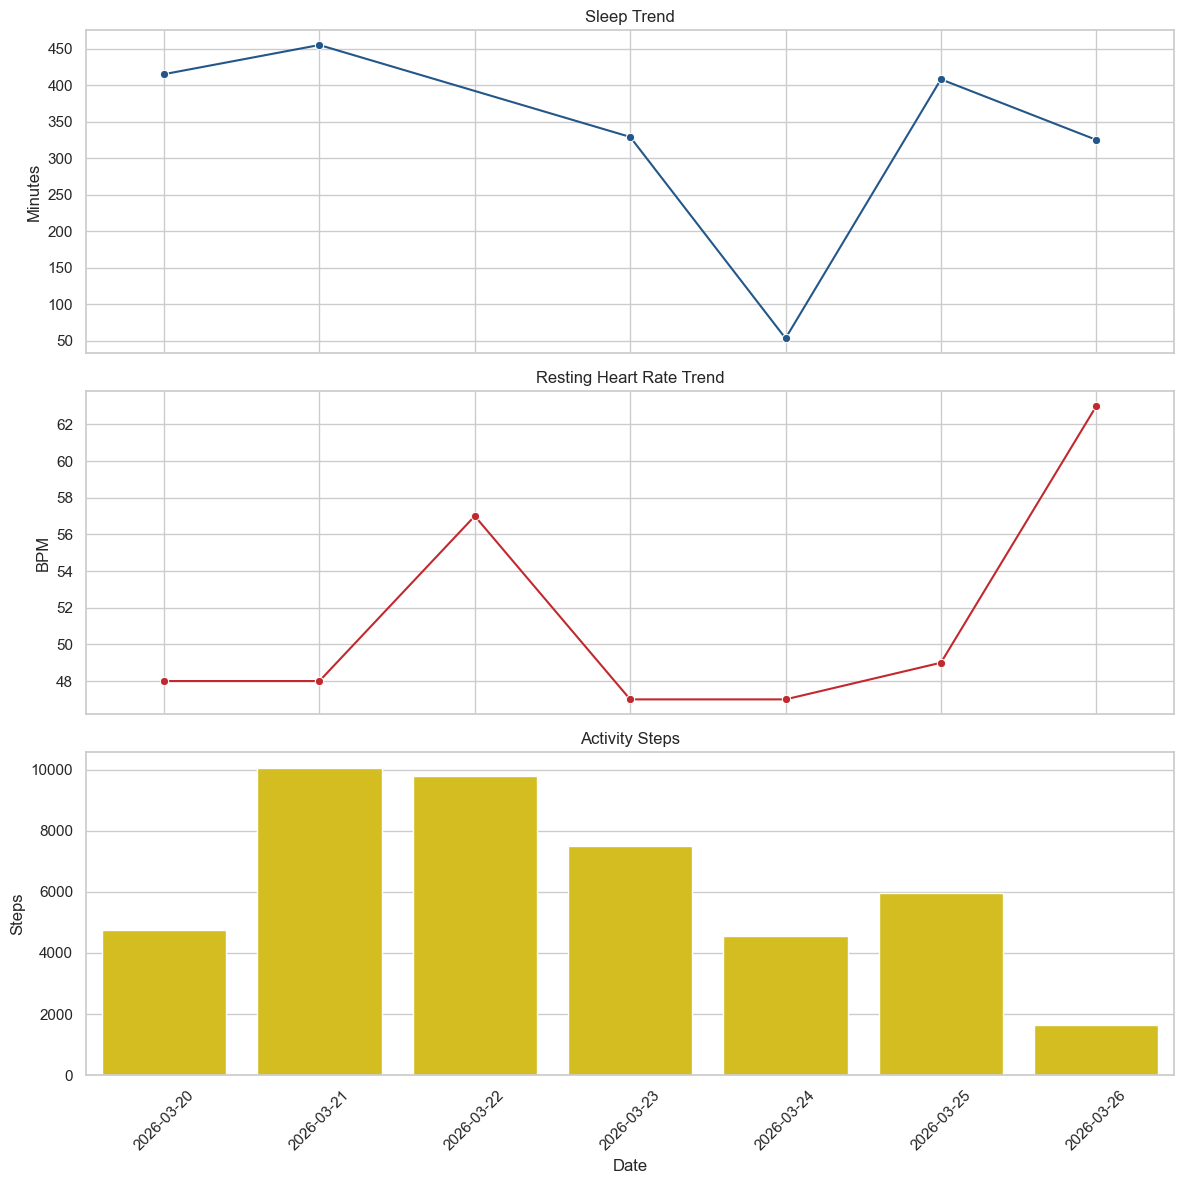

In [3]:
sns.set_theme(style="whitegrid")
plot_df = health_df.copy()
plot_df["date_label"] = pd.to_datetime(plot_df["date"]).dt.strftime("%Y-%m-%d")

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

sns.lineplot(
    data=plot_df,
    x="date_label",
    y="sleep_total_minutes",
    marker="o",
    sort=False,
    ax=axes[0],
    color="#235789",
)
axes[0].set_title("Sleep Trend")
axes[0].set_ylabel("Minutes")

sns.lineplot(
    data=plot_df,
    x="date_label",
    y="resting_hr_bpm",
    marker="o",
    sort=False,
    ax=axes[1],
    color="#c1292e",
)
axes[1].set_title("Resting Heart Rate Trend")
axes[1].set_ylabel("BPM")

sns.barplot(
    data=plot_df,
    x="date_label",
    y="activity_steps",
    ax=axes[2],
    color="#f1d302",
)
axes[2].set_title("Activity Steps")
axes[2].set_ylabel("Steps")
axes[2].set_xlabel("Date")

for axis in axes:
    axis.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 4. Readiness

In [4]:
readiness_report = readiness_use_case.execute(
    BuildReadinessReportInput(
        end_date=DEMO_END_DATE,
        days=DEMO_DAYS,
        include_narrative=False,
    )
)

display(readiness_report.readiness)
display(Markdown(readiness_report.markdown))


DailyReadiness(date=datetime.date(2026, 3, 26), readiness_score=86.9, sleep_efficiency_pct=96.4, resting_hr_trend=1.321, load_ratio=0.6, data_gaps=[], warnings=['Resting heart rate is trending upward, which can indicate incomplete recovery.'])

# Daily Readiness Report — 2026-03-26

## Metrics

| Metric | Value |
|--------|-------|
| Readiness Score | 87/100 |
| Sleep Efficiency | 96.4% |
| Resting HR Trend | +1.32 bpm/day |
| Load Ratio | 0.60 |
| Days Analyzed | 7 |
| Data Gaps | 0 days |

## Warnings

- Resting heart rate is trending upward, which can indicate incomplete recovery.

## Analysis

Readiness is strong today, with recovery signals supporting normal or ambitious effort.
Recovery summary: Sleep efficiency was 96.4%; resting heart rate trend was +1.32 bpm/day.
Activity load is below baseline. If you feel good, a controlled progression day may be appropriate.
The seven-day window had no fully missing days.

## 5. Narrative LLM

In [5]:
llm_report = readiness_use_case.execute(
    BuildReadinessReportInput(
        end_date=DEMO_END_DATE,
        days=DEMO_DAYS,
        include_narrative=True,
    )
)

display(Markdown(llm_report.narrative))


{"provider": "openai", "operation": "generate", "readiness_date": "2026-03-26", "available_days": 7, "event": "llm_generate_requested", "level": "info", "timestamp": "2026-03-26T16:25:11.647979Z"}
HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
{"provider": "openai", "operation": "generate", "duration_ms": 4333.35, "response_length": 972, "event": "llm_generate_succeeded", "level": "info", "timestamp": "2026-03-26T16:25:15.981289Z"}


```markdown
## Summary  
The overall readiness score for today is 86.9, indicating a strong state for performance. Sleep efficiency remains high at 96.4%, supporting recovery. Resting heart rate shows a moderate upward trend (1.321), and the load ratio is low (0.6), suggesting a manageable training intensity. There are no missing data days in the past week.

## Recommendations  
- Prioritize consistent sleep duration and maintain current sleep quality to support ongoing recovery.  
- Keep training intensity moderate given the low load ratio, allowing room for gradual increases if desired.  
- Monitor resting heart rate trends for any significant changes that might indicate a need for additional rest.  
- Maintain adequate hydration to support overall performance and recovery.

## Data Quality  
Data is complete with no missing days in the past week, supporting confidence in the assessment. Continued accurate tracking is recommended for reliable insights.
```

## 6. Interactive Chat

In [6]:
print("Ask questions about your readiness, sleep, activity, or heart rate.")
print("Type 'exit' to stop the loop.")

while True:
    question = input("You: ").strip()
    if question.lower() in {"exit", "quit", "q"}:
        print("Chat ended.")
        break
    if not question:
        continue

    answer = chat_use_case.execute(
        ChatWithHealthDataInput(
            end_date=DEMO_END_DATE,
            days=DEMO_DAYS,
            question=question,
        )
    )
    print(f"Assistant: {answer}\n")


Ask questions about your readiness, sleep, activity, or heart rate.
Type 'exit' to stop the loop.
{"provider": "openai", "operation": "chat", "question": "how was my last night?", "available_days": 7, "event": "llm_chat_requested", "level": "info", "timestamp": "2026-03-26T16:25:30.451784Z"}
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
{"provider": "openai", "operation": "chat", "duration_ms": 2525.02, "response_length": 124, "event": "llm_chat_succeeded", "level": "info", "timestamp": "2026-03-26T16:25:32.976827Z"}
Assistant: On the night of March 26, 2026, you slept for 325 minutes, had a resting heart rate (RHR) of 63.0 bpm, and took 1,647 steps.

Chat ended.
